K-Medians Clustering


K-Medians is almost the same as K-Means with one difference:
- K-Means uses the **mean (average)** to find the cluster centre
- K-Medians uses the **median (middle value)** to find the cluster centre

The median is not affected by extreme values. So if one customer has not transacted in 513 days while everyone else is under 5 days, K-Medians handles that better.



In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import RobustScaler
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

plt.style.use('ggplot')

In [28]:
df = pd.read_csv('credit_card_transactions.csv')
if 'Unnamed: 0' in df.columns:
    df = df.drop(columns=['Unnamed: 0'])

df['trans_date_trans_time'] = pd.to_datetime(df['trans_date_trans_time'])
df['dob']                   = pd.to_datetime(df['dob'], errors='coerce')
df['age'] = (df['trans_date_trans_time'] - df['dob']).dt.days / 365.25

for col in ['amt', 'age', 'city_pop']:
    Q1, Q3 = df[col].quantile(0.25), df[col].quantile(0.75)
    IQR    = Q3 - Q1
    df     = df[(df[col] >= Q1 - 1.5*IQR) & (df[col] <= Q3 + 1.5*IQR)]

ref_date = df['trans_date_trans_time'].max() + pd.Timedelta(days=1)
rfm = df.groupby('cc_num').agg(
    Recency   = ('trans_date_trans_time', lambda x: (ref_date - x.max()).days),
    Frequency = ('trans_num', 'count'),
    Monetary  = ('amt', 'sum'),
).reset_index()

rfm['Recency_log']  = np.log1p(rfm['Recency'])
rfm['Monetary_log'] = np.log1p(rfm['Monetary'])

cols_to_cluster = ['Recency_log', 'Frequency', 'Monetary_log']
scaler = RobustScaler()
X = scaler.fit_transform(rfm[cols_to_cluster])

print('Customers:', len(rfm))
print('Scaled array:', X.shape)

Customers: 781
Scaled array: (781, 3)


In [29]:
def k_medians(X, k, max_iter=100, random_state=42):
    rng = np.random.RandomState(random_state)

    # Step 1: pick k random starting points as our first centroids
    idx       = rng.choice(len(X), k, replace=False)
    centroids = X[idx].copy()
    labels    = np.zeros(len(X), dtype=int)

    for iteration in range(max_iter):

        # Step 2: measure distance from every point to every centroid
        # We use Manhattan distance = sum of absolute differences
        # (works better with median than Euclidean distance)
        dists = np.abs(X[:, None, :] - centroids[None, :, :]).sum(axis=2)

        # Step 3: assign each point to its nearest centroid
        new_labels = dists.argmin(axis=1)

        # Step 4: recalculate centroids using MEDIAN (not mean like K-Means)
        new_centroids = np.array([
            np.median(X[new_labels == i], axis=0) for i in range(k)
        ])

        # Step 5: if centroids stopped moving, we are done
        if np.allclose(centroids, new_centroids):
            print(f'  Converged after {iteration + 1} iterations')
            break

        centroids = new_centroids
        labels    = new_labels

    return new_labels, centroids

print('K-Medians function defined and ready to use.')

K-Medians function defined and ready to use.


Choose K — try different values and compare

In [30]:
# We try K = 2 to 7 and check silhouette score each time
print('K    Silhouette Score')
print('-' * 25)

sil_scores = []
K_range    = range(2, 8)

for k in K_range:
    labels, _ = k_medians(X, k=k)
    score     = silhouette_score(X, labels)
    sil_scores.append(score)
    print(f'K={k}   {score:.3f}')

K    Silhouette Score
-------------------------
  Converged after 5 iterations
K=2   0.360
  Converged after 13 iterations
K=3   0.237
  Converged after 15 iterations
K=4   0.234
  Converged after 8 iterations
K=5   0.255
  Converged after 4 iterations
K=6   0.201
  Converged after 7 iterations
K=7   0.207


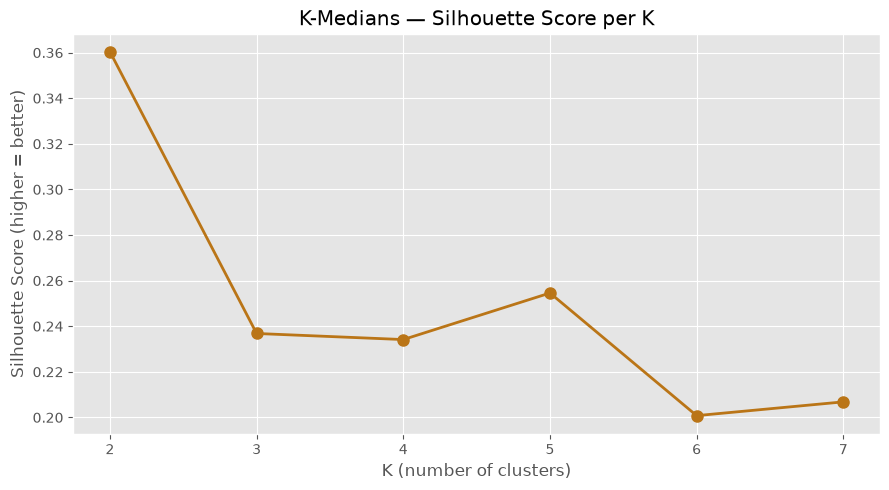

Best K by silhouette: 2
We use K=4 to match K-Means and compare fairly


In [31]:
plt.figure(figsize=(9, 5))
plt.plot(K_range, sil_scores, marker='o', color='#BA7517', linewidth=2, markersize=8)
plt.title('K-Medians — Silhouette Score per K')
plt.xlabel('K (number of clusters)')
plt.ylabel('Silhouette Score (higher = better)')
plt.xticks(K_range)
plt.tight_layout()
plt.show()

best_k = list(K_range)[sil_scores.index(max(sil_scores))]
print(f'Best K by silhouette: {best_k}')
print('We use K=4 to match K-Means and compare fairly')

Run K-Medians with K=4

In [32]:
K = 4

labels_kmed, centroids_kmed = k_medians(X, k=K)
rfm['KMed_Cluster'] = labels_kmed

print(f'K-Medians run with K={K}')
print()
print('Customers per cluster:')
print(pd.Series(labels_kmed).value_counts().sort_index())

  Converged after 15 iterations
K-Medians run with K=4

Customers per cluster:
0    128
1    284
2    217
3    152
Name: count, dtype: int64


In [33]:
profile_kmed = rfm.groupby('KMed_Cluster')[['Recency','Frequency','Monetary']].mean().round(1)

print('K-Medians cluster profiles:')
print(profile_kmed.to_string())
print()

# Name based on profile
# Cluster 0: low recency, highest frequency/spend → High Value
# Cluster 1: low recency, high-medium frequency   → Medium-High Value
# Cluster 2: higher recency, lower spend          → At Risk / Low Value
# Cluster 3: low recency, moderate freq/spend     → Medium Value

cluster_names_kmed = {
    0: 'High Value',
    1: 'Medium-High',
    2: 'At Risk',
    3: 'Medium Value',
}

rfm['KMed_Name'] = rfm['KMed_Cluster'].map(cluster_names_kmed)
print('Named sizes:')
print(rfm['KMed_Name'].value_counts())

K-Medians cluster profiles:
              Recency  Frequency  Monetary
KMed_Cluster                              
0                 1.0     2434.5  126873.1
1                 1.0     1608.1   81700.8
2                61.0      382.9   19993.2
3                 1.1      978.1   47287.3

Named sizes:
KMed_Name
Medium-High     284
At Risk         217
Medium Value    152
High Value      128
Name: count, dtype: int64


Compare K-Medians vs K-Means side by side

In [34]:
# Load K-Means results
km_df = pd.read_csv('cc_kmeans_output.csv')

print('=== K-MEANS cluster profiles ===')
km_prof = km_df.groupby('Cluster_Name')[['Recency','Frequency','Monetary']].mean().round(1)
print(km_prof.sort_values('Monetary', ascending=False).to_string())

print()
print('=== K-MEDIANS cluster profiles ===')
kmed_prof = rfm.groupby('KMed_Name')[['Recency','Frequency','Monetary']].mean().round(1)
print(kmed_prof.sort_values('Monetary', ascending=False).to_string())

=== K-MEANS cluster profiles ===
              Recency  Frequency  Monetary
Cluster_Name                              
High Value        1.0     2159.8  111226.7
Medium Value      1.1     1206.5   60038.0
Low Value         1.5      488.5   25841.6
Dormant         276.4        2.6      61.8

=== K-MEDIANS cluster profiles ===
              Recency  Frequency  Monetary
KMed_Name                                 
High Value        1.0     2434.5  126873.1
Medium-High       1.0     1608.1   81700.8
Medium Value      1.1      978.1   47287.3
At Risk          61.0      382.9   19993.2


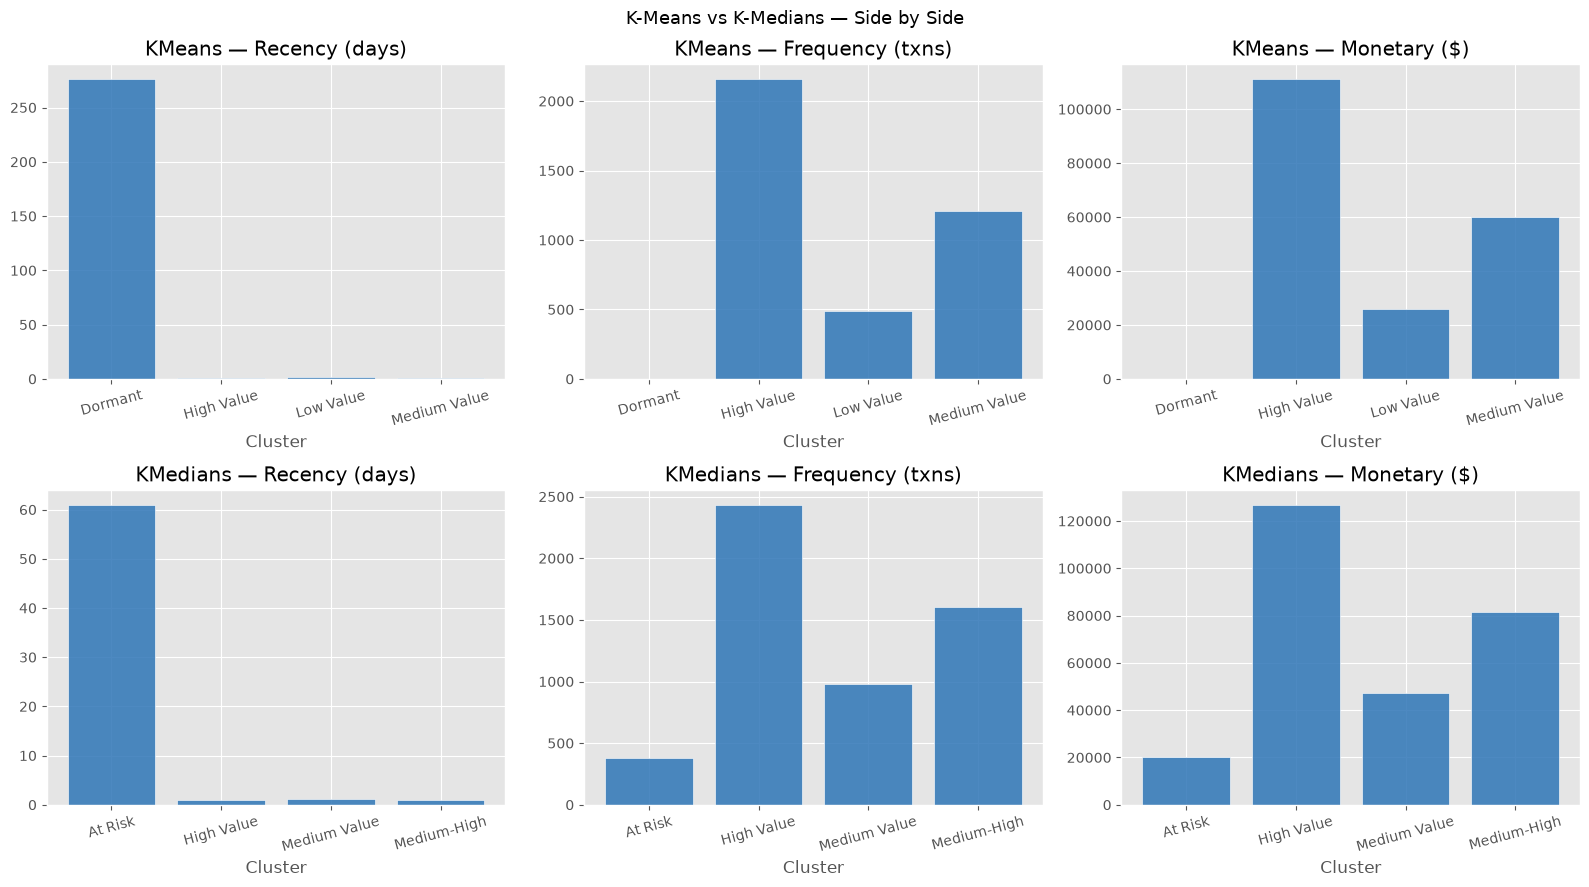

In [35]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))

for row_i, (data, name, col) in enumerate([
    (km_df,  'KMeans',   'Cluster_Name'),
    (rfm,    'KMedians', 'KMed_Name'),
]):
    for col_i, (metric, label) in enumerate(zip(
        ['Recency','Frequency','Monetary'],
        ['Recency (days)','Frequency (txns)','Monetary ($)']
    )):
        grp = data.groupby(col)[metric].mean().round(1)
        axes[row_i, col_i].bar(grp.index, grp.values, color='#2E75B6', edgecolor='white', alpha=0.85)
        axes[row_i, col_i].set_title(f'{name} — {label}')
        axes[row_i, col_i].set_xlabel('Cluster')
        axes[row_i, col_i].tick_params(axis='x', rotation=15)

plt.suptitle('K-Means vs K-Medians — Side by Side', fontsize=13)
plt.tight_layout()
plt.show()

Evaluate K-Medians

 Silhouette Score

In [36]:
sil_kmed = silhouette_score(X, labels_kmed)
print(f'K-Medians Silhouette Score (K=4): {sil_kmed:.3f}')
print()

# Also get K-Means score for comparison
from sklearn.cluster import KMeans
km_check = KMeans(n_clusters=4, init='k-means++', random_state=42, n_init=10)
labels_km = km_check.fit_predict(X)
sil_km = silhouette_score(X, labels_km)
print(f'K-Means   Silhouette Score (K=4): {sil_km:.3f}')
print()
if sil_kmed >= sil_km:
    print('K-Medians has equal or better silhouette — use it as the primary model')
else:
    diff = sil_km - sil_kmed
    print(f'K-Means has a slightly better silhouette by {diff:.3f}')
    print('This means K-Means clustering is cleaner on this data')

K-Medians Silhouette Score (K=4): 0.234

K-Means   Silhouette Score (K=4): 0.552

K-Means has a slightly better silhouette by 0.318
This means K-Means clustering is cleaner on this data


 Cluster size check

In [38]:
sizes = rfm['KMed_Name'].value_counts()
print('K-Medians cluster sizes:')
print(sizes)
print()
print(f'Smallest cluster: {sizes.min()} customers ({sizes.min()/len(rfm)*100:.1f}%)')
print(f'Largest cluster : {sizes.max()} customers ({sizes.max()/len(rfm)*100:.1f}%)')

K-Medians cluster sizes:
KMed_Name
Medium-High     284
At Risk         217
Medium Value    152
High Value      128
Name: count, dtype: int64

Smallest cluster: 128 customers (16.4%)
Largest cluster : 284 customers (36.4%)


Which model should to use

In [39]:
print('Summary comparison:')
print()
print(f'  K-Means   Silhouette: {sil_km:.3f}')
print(f'  K-Medians Silhouette: {sil_kmed:.3f}')
print()
print('Rule of thumb:')
print('  If silhouette scores are similar → either model works')
print('  If data has extreme outliers → K-Medians is more trustworthy')
print('  For presentations → K-Means is better known and easier to explain')
print()

rfm.to_csv('cc_kmedians_output.csv', index=False)
print()

Summary comparison:

  K-Means   Silhouette: 0.552
  K-Medians Silhouette: 0.234

Rule of thumb:
  If silhouette scores are similar → either model works
  If data has extreme outliers → K-Medians is more trustworthy
  For presentations → K-Means is better known and easier to explain




SINCE K-MEANS is the more widely known algorithm, we will use it as the primary model for this dataset.